## *Proposition de workflow pour le process de données µSAXS*






#### **Etape 1: Conversion d'un fichier h5 en edf**

On utilise la méthode 'convert2edf' de la classe h5File_SWING, en précisant bien qu'on ne veut PAS moyenner les images (passer l'argument mean=False lors de l'instantiation de la classe).
Remarque: Dans le parser du format edf, le binning est par défaut 1. Par conséquent, la taille des pixels est mutlipliée par les paramètres de binning pendant la conversion en format edf.

In [11]:
%matplotlib widget
from saxsprocessor import SAXSProcessor
import glob
import os
import numpy as np
from matplotlib import pyplot as plt
import re
from utilities_SWING import *
import pandas as pd
from filereaders import h5File_SWING
from utilities import *

# Make pyfai warning silent (optional, but nicer output)
import logging, warnings

logging.getLogger("pyFAI").setLevel(logging.ERROR)
logging.getLogger("fabio").setLevel(logging.ERROR)

warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide",
    module="pyFAI"
)


On convertit le fichier et sa référence en fichiers edf qui correspondent aux differents points, grace à la fonction convert2edf

In [12]:

from pathlib import Path

testfile = Path('T:/LPCNO/NCO/Manips/DATA_SAXS/SWING_align_fev26/20250369/2026/Run1/lacroix/s0000/lacroix_00186_2026-02-06_15-50-57.nxs')
edfpath = testfile.parent / "cartographie" / testfile.stem
edfpath.mkdir(parents=True, exist_ok=True)
edfpath = str(edfpath)

reference = Path('T:/LPCNO/NCO/Manips/DATA_SAXS/SWING_align_fev26/20250369/2026/Run1/lacroix/e0000/lacroix_00177_2026-02-06_12-42-54.nxs')
edfpathr = reference.parent / "cartographie" / reference.stem
edfpathr.mkdir(parents=True, exist_ok=True)
edfpathr = str(edfpathr)

file = h5File_SWING(testfile, mean = False) # we do not average data contained in this file, we force linescan (step_z=0)
filer = h5File_SWING(reference, mean = False)

# Convert mask from SWING mask (just to show it is possible)
#mask = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/mask_lacroix_jul24.txt'
#mask=file.convert_SWING_mask(maskfile=mask)

# as beamstop is missing on this mask, we use the following file:
mask = 'mask_pyfai.edf'


filer.convert2edf(outputdir=edfpathr)

# convert h5file to edf files
file.convert2edf(outputdir=edfpath)

print(f'Scan parameters: xstart = {file.position_x_start}, step x: {file.step_x}, zstart={file.position_z_start},step_z:{file.step_z}')


position moteur :
{'X_start': array([37.6994]), 'X_end': array([38.4996]), 'Z_start': array([39.4996]), 'Z_end': array([41.3999])}
{'X_start': array([37.6994]), 'X_end': array([38.4996]), 'Z_start': array([39.4996]), 'Z_end': array([41.3999])}
step :
[0.08891111]
[0.095015]
180
Raw data shape: (9, 20, 1083, 1035)
info
9
20
position moteur :
{'X_start': array([36.6996]), 'X_end': array([38.5998]), 'Z_start': array([39.4997]), 'Z_end': array([41.4001])}
{'X_start': array([36.6996]), 'X_end': array([38.5998]), 'Z_start': array([39.4997]), 'Z_end': array([41.4001])}
step :
[0.09501]
[0.09502]
400
Raw data shape: (20, 20, 1083, 1035)
info
20
20
0
convert
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [1 0 1 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [1 0 0 ... 0 0 0]]
transmission [[-0.0627653  -0.04995494 -0.07443009 -0.07579319 -0.09191609 -0.06188456
  -0.07138284 -0.08036789 -0.11187322 -0.10902318 -0.04467674 -0.0649973
  -0.07173073 -0.06257617 -0.05361695 -0.05329838 -0.02941125 

In [13]:
print(str(testfile.parent))
print(file.data.shape)
print(file.data.shape[1])
print(file.data.shape[0])

T:\LPCNO\NCO\Manips\DATA_SAXS\SWING_align_fev26\20250369\2026\Run1\lacroix\s0000
(9, 20, 1083, 1035)
20
9


#### **Etape 2: Classement des fichiers individuels en liste**


In [14]:
from saxsprocessor import SAXSProcessor
import glob
import os
import numpy as np
from matplotlib import pyplot as plt
import re


# retrieve the number of points from the h5file
file_filter = '*Img*.edf'  # be careful not to include the mask in this list
instrument = 'LGC'

# Establish a list of files
filelist = glob.glob(os.path.join(edfpath,file_filter))
filelistr = glob.glob(os.path.join(edfpathr,file_filter))

print(filelist)
print(filelistr)
# Sort the file list (we need to define a function)
# files are sorted by File_number.Img 


def parse_img(file):
    match = re.search(r'img_(\d+)_(\d+)', file, re.IGNORECASE)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None  # fichier non conforme

# On filtre : conserve seulement les fichiers valides
valid_files = [f for f in filelist if parse_img(f) is not None]
valid_filesr = [f for f in filelistr if parse_img(f) is not None]

# On trie uniquement les fichiers valides
sorted_files = sorted(valid_files, key=lambda f: parse_img(f))
sorted_filesr = sorted(valid_filesr, key=lambda f: parse_img(f))

print(sorted_files)
print(sorted_filesr)







['T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0000\\cartographie\\lacroix_00186_2026-02-06_15-50-57\\S0000_M0125_File_186_Img_0_0.edf', 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0000\\cartographie\\lacroix_00186_2026-02-06_15-50-57\\S0000_M0125_File_186_Img_0_1.edf', 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0000\\cartographie\\lacroix_00186_2026-02-06_15-50-57\\S0000_M0125_File_186_Img_0_2.edf', 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0000\\cartographie\\lacroix_00186_2026-02-06_15-50-57\\S0000_M0125_File_186_Img_0_3.edf', 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0000\\cartographie\\lacroix_00186_2026-02-06_15-50-57\\S0000_M0125_File_186_Img_0_4.edf', 'T:\\LPCNO\\NCO\\Manips\\DATA_SAXS\\SWING_align_fev26\\20250369\\2026\\Run1\\lacroix\\s0000\\cartographie\\lacroix

Ici on peut extraire l'image 2d, le paramêtre d'ordre ainsi que les profils radiaux de n'importe quel point du fichier h5.

(1083, 1035)
✅ SAXS image saved: T:\LPCNO\NCO\Manips\DATA_SAXS\SWING_align_fev26\20250369\2026\Run1\lacroix\s0000\cartographie\lacroix_00186_2026-02-06_15-50-57/saxs_images/S0000_M0125_Img_8.png


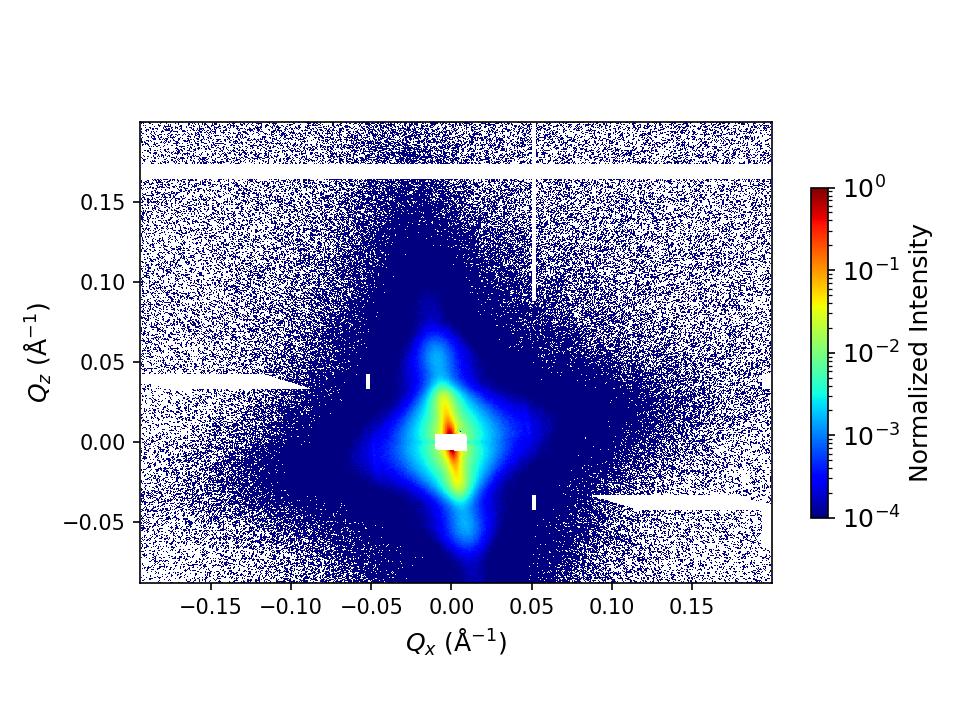

'\nS, orientation, results = compute_nematic_parameter(\n    processor=proc,\n    qvalue=qvalue,\n    threshold=0.05,\n    radius=diametre/2,\n    L=AS*diametre,\n    radius_pd=diametre_pd/2,\n    L_pd=L_pd,\n    plot=True,\n    apply_mirror=False,\n    verbose=True,\n)'

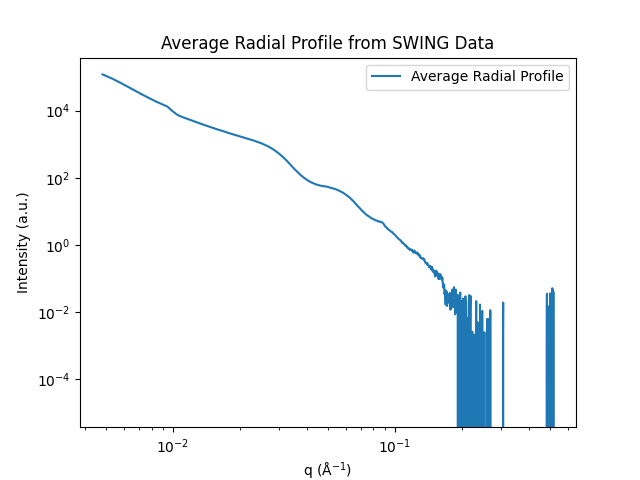

In [15]:
# je choisis d'extraire un point de référence situé au milieu de l'échantillon
refmil = sorted_filesr[220]
file1r = sorted_files[8]

proc = SAXSProcessor(file1r, reference_file=refmil,autosubstract=False, mask=mask, instrument='LGC') # instrument is set to 'LGC' as we are dealing with edf files now.
# Use dedicated function to plot average SAXS image
q,Ir = proc.extract_radial_profile(azimuth=0, width=360)
proc.plot2d_vsq()

plt.figure()
plt.loglog(q, Ir, label='Average Radial Profile')
plt.xlabel('q (Å$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Average Radial Profile from SWING Data')
plt.legend()


# A automatiser avec le exel
AS = 8.38
diametre = 183
diametre_pd = 0.1421
L_pd=0.1569  
qvalue = 0.0567


'''
S, orientation, results = compute_nematic_parameter(
    processor=proc,
    qvalue=qvalue,
    threshold=0.05,
    radius=diametre/2,
    L=AS*diametre,
    radius_pd=diametre_pd/2,
    L_pd=L_pd,
    plot=True,
    apply_mirror=False,
    verbose=True,
)'''






Ici on fait la cartographie de notre fichier h5.

Attention à ne pas oublier de renseigner le nombre de colonne et de ligne de la carto ( à automatiser )

In [6]:
print(refmil)
print(str(testfile.parent))

T:\LPCNO\NCO\Manips\DATA_SAXS\SWING_align_fev26\20250369\2026\Run1\lacroix\e0000\cartographie\lacroix_00177_2026-02-06_12-42-54\E0000_M0116_File_177_Img_11_0.edf
T:\LPCNO\NCO\Manips\DATA_SAXS\SWING_align_fev26\20250369\2026\Run1\lacroix\s0000


⚠️ WARNING: This function assumes the data correspond to a linescan.


[Parallel(n_jobs=27)]: Using backend LokyBackend with 27 concurrent workers.
[Parallel(n_jobs=27)]: Done   2 out of   9 | elapsed:  2.0min remaining:  6.9min
[Parallel(n_jobs=27)]: Done   3 out of   9 | elapsed:  2.0min remaining:  4.0min
[Parallel(n_jobs=27)]: Done   4 out of   9 | elapsed:  2.0min remaining:  2.5min
[Parallel(n_jobs=27)]: Done   5 out of   9 | elapsed:  2.0min remaining:  1.6min
[Parallel(n_jobs=27)]: Done   6 out of   9 | elapsed:  2.0min remaining:   59.9s
[Parallel(n_jobs=27)]: Done   7 out of   9 | elapsed:  2.0min remaining:   34.2s
[Parallel(n_jobs=27)]: Done   9 out of   9 | elapsed:  4.0min finished


0 37.699400000000004 39.4996
1 37.78831111111111 39.4996
2 37.87722222222222 39.4996
3 37.699400000000004 39.594615000000005
4 37.78831111111111 39.594615000000005
5 37.87722222222222 39.594615000000005
6 37.699400000000004 39.68963
7 37.78831111111111 39.68963
8 37.87722222222222 39.68963
Carte 2 S [[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


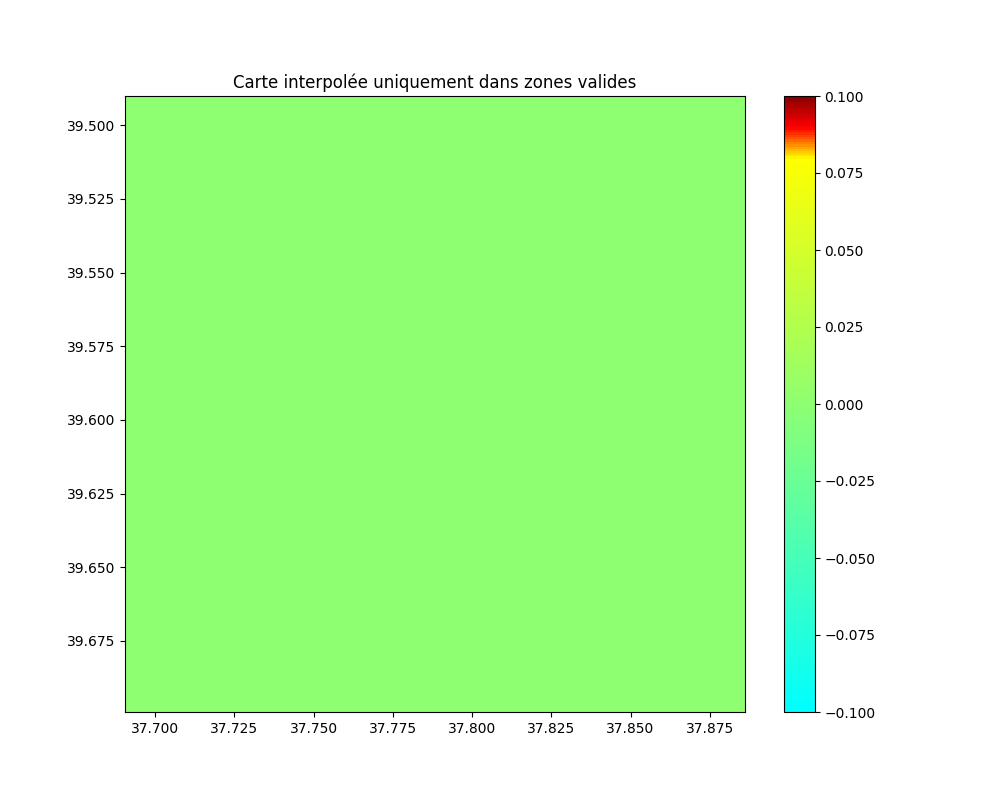

In [7]:

x_2d, z_2d, orientation_2d, S_2d, R2_2d = compute_nematic_order_assembly_SWING(
    h5path=str(testfile.parent),
    mask=mask,
    filelist=sorted_files,
    autosubstract=False,
    reference_file = refmil, 
    qvalue=qvalue,
    threshold=0.05,
    radius=diametre/2,
    L=AS*diametre,
    radius_pd=diametre_pd/2,
    L_pd=L_pd,
    plot=True,
    apply_mirror=False,
    verbose=True,
    nb_ligne=3,  # A integrer proprement dans la fonction
    nb_colonne=3
    )